In [24]:
import scanpy as sc

In [25]:
import celltypist
from celltypist import models


In [26]:
adata_2000 = sc.read('celltypist_demo_folder/demo_2000_cells.h5ad', backup_url = 'https://celltypist.cog.sanger.ac.uk/Notebook_demo_data/demo_2000_cells.h5ad')

In [27]:
adata_2000.shape

(2000, 18950)

In [28]:
adata_2000.X.expm1().sum(axis = 1)

matrix([[10000.   ],
        [10000.002],
        [10000.   ],
        ...,
        [10000.   ],
        [10000.   ],
        [ 9999.999]], shape=(2000, 1), dtype=float32)

In [29]:
adata_2000.obs

,cell_type
cell1,Plasma cells
cell2,Plasma cells
cell3,Plasma cells
cell4,Plasma cells
cell5,Plasma cells
...,...
cell1996,Neutrophil-myeloid progenitor
cell1997,Neutrophil-myeloid progenitor
cell1998,Neutrophil-myeloid progenitor
cell1999,Neutrophil-myeloid progenitor


In [30]:
models.download_models(force_update = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in C:\Users\eok33\.celltypist\data\models
💾 Downloading model [1/61]: Immune_All_Low.pkl
💾 Downloading model [2/61]: Immune_All_High.pkl
💾 Downloading model [3/61]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/61]: Adult_Human_MTG.pkl
💾 Downloading model [6/61]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/61]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/61]: Adult_Human_Skin.pkl
💾 Downloading model [9/61]: Adult_Human_Vascular.pkl
💾 Downloading model [10/61]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/61]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/61]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/61]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/61]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/61]: Adult_cHSPCs_Ultima.pkl
💾 

In [31]:
'/home/jovyan/.celltypist/data/models'

'/home/jovyan/.celltypist/data/models'

In [32]:
model = models.Model.load(model = 'Pan_Fetal_Human.pkl')

In [33]:
model

CellTypist model with 138 cell types and 7204 features
    date: 2022-04-23 11:40:27.484223
    details: stromal and immune populations from the human fetus
    source: https://doi.org/10.1126/science.abo0510
    version: v2
    cell types: ABT(ENTRY), AS_DC, ..., YS_STROMA
    features: TSPAN6, TNMD, ..., LINC00842

In [34]:
model.cell_types

array(['ABT(ENTRY)', 'AS_DC', 'B1', 'CD4+T', 'CD8+T', 'CD8AA',
       'CHONDROCYTE', 'CMP', 'CYCLING_B', 'CYCLING_DC',
       'CYCLING_EPITHELIUM', 'CYCLING_FIBROBLAST_I',
       'CYCLING_FIBROBLAST_II', 'CYCLING_ILC', 'CYCLING_MEMP',
       'CYCLING_MPP', 'CYCLING_NK', 'CYCLING_PDC', 'CYCLING_T',
       'CYCLING_YS_ERY', 'DC1', 'DC2', 'DC_PROGENITOR',
       'DEVELOPING_NEPHRON_I', 'DEVELOPING_NEPHRON_II', 'DN(P)_T',
       'DN(Q)_T', 'DN(early)_T', 'DOUBLET', 'DOUBLETS_FIBRO_ERY',
       'DOUBLET_ENDOTHELIUM_ERYTHROCYTE', 'DOUBLET_ERY_B',
       'DOUBLET_IMMUNE_FIBROBLAST', 'DOUBLET_LYMPHOID_MACROPHAGE',
       'DOUBLET_VSMC_ERYTHROCYTE', 'DP(P)_T', 'DP(Q)_T', 'EARLY_ERY',
       'EARLY_MK', 'ENDOTHELIUM_I', 'ENDOTHELIUM_II', 'ENDOTHELIUM_III',
       'ENDOTHELIUM_IV', 'ENDOTHELIUM_V', 'ENTEROENDOCRINE_I',
       'ENTEROENDOCRINE_II', 'EOSINOPHIL_BASOPHIL', 'EPITHELIUM_I',
       'EPITHELIUM_II', 'FIBROBLAST_I', 'FIBROBLAST_II', 'FIBROBLAST_III',
       'FIBROBLAST_IV', 'FIBROBLAST_I

In [35]:
predictions = celltypist.annotate(adata_2000, model = 'Immune_All_Low.pkl', majority_voting = True)

🔬 Input data has 2000 cells and 18950 genes
🔗 Matching reference genes in the model
🧬 5645 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


In [36]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
cell1,Plasma cells,0,Plasma cells
cell2,Plasma cells,1,Plasma cells
cell3,Plasma cells,2,gamma-delta T cells
cell4,Plasma cells,3,Plasma cells
cell5,Plasma cells,3,Plasma cells
...,...,...,...
cell1996,HSC/MPP,43,Neutrophil-myeloid progenitor
cell1997,Neutrophil-myeloid progenitor,42,Neutrophil-myeloid progenitor
cell1998,Neutrophil-myeloid progenitor,40,Neutrophil-myeloid progenitor
cell1999,Neutrophil-myeloid progenitor,42,Neutrophil-myeloid progenitor


In [37]:
adata = predictions.to_adata()

In [38]:
adata.obs

,cell_type,predicted_labels,over_clustering,majority_voting,conf_score
cell1,Plasma cells,Plasma cells,0,Plasma cells,0.999762
cell2,Plasma cells,Plasma cells,1,Plasma cells,0.999926
cell3,Plasma cells,Plasma cells,2,gamma-delta T cells,0.955991
cell4,Plasma cells,Plasma cells,3,Plasma cells,0.999883
cell5,Plasma cells,Plasma cells,3,Plasma cells,0.999890
...,...,...,...,...,...
cell1996,Neutrophil-myeloid progenitor,HSC/MPP,43,Neutrophil-myeloid progenitor,0.152962
cell1997,Neutrophil-myeloid progenitor,Neutrophil-myeloid progenitor,42,Neutrophil-myeloid progenitor,0.810408
cell1998,Neutrophil-myeloid progenitor,Neutrophil-myeloid progenitor,40,Neutrophil-myeloid progenitor,0.961021
cell1999,Neutrophil-myeloid progenitor,Neutrophil-myeloid progenitor,42,Neutrophil-myeloid progenitor,0.131777


In [39]:
sc.tl.umap(adata)

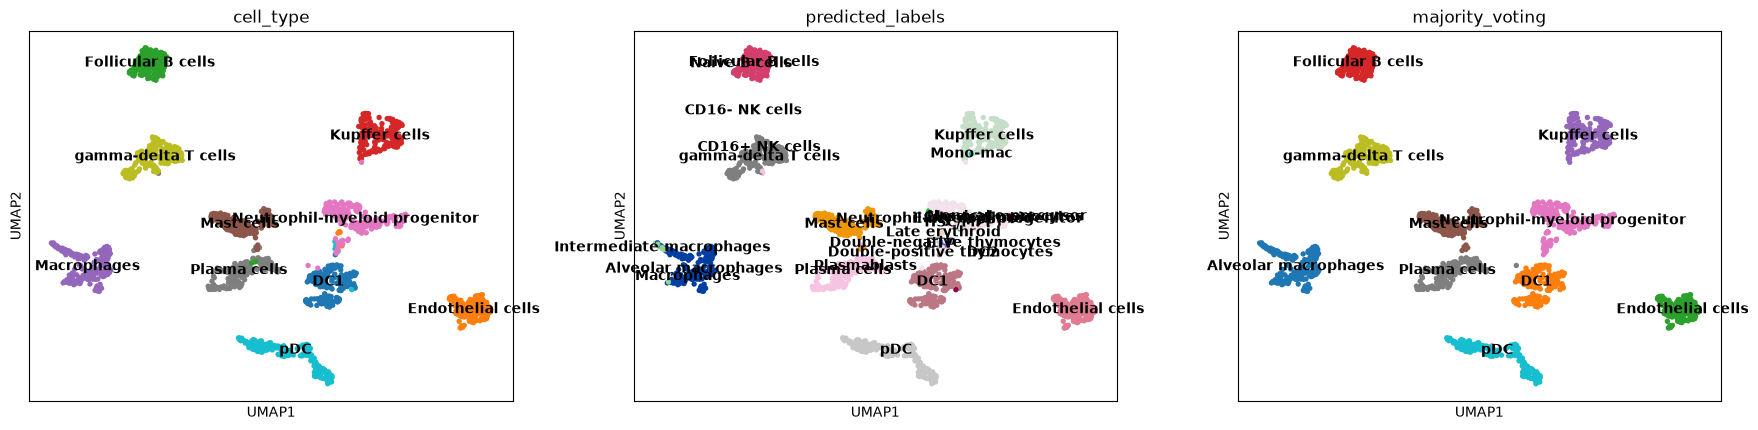

In [40]:
sc.pl.umap(adata, color = ['cell_type', 'predicted_labels', 'majority_voting'], legend_loc = 'on data')

In [41]:
from __future__ import annotations

import anndata as ad

# Data retrieval
import pooch
import scanpy as sc

In [42]:
sc.settings.set_figure_params(dpi=50, facecolor="white")

In [43]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)
EXAMPLE_DATA.load_registry_from_doi()

In [44]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata

sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'
    layers: None (.X)

In [45]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [46]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

In [47]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [48]:
model

CellTypist model with 138 cell types and 7204 features
    date: 2022-04-23 11:40:27.484223
    details: stromal and immune populations from the human fetus
    source: https://doi.org/10.1126/science.abo0510
    version: v2
    cell types: ABT(ENTRY), AS_DC, ..., YS_STROMA
    features: TSPAN6, TNMD, ..., LINC00842

In [ ]:
model = models.model.load(model = )